In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")

df_train = pd.read_csv("sen_noc1.csv")
df_test = pd.read_csv("sen_noc2.csv")

FEATURES = ['BPM_Srednie', 'HRV', 'Energia_Ruchu']
TARGET = 'Faza_Snu'
LABELS = ['Wybudzenie', 'Sen Płytki', 'Sen Głęboki', 'Faza REM']

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_test, y_test = df_test[FEATURES], df_test[TARGET]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/tmp/ipykernel_1282/3042408824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=TARGET, y=feature, data=df_train, palette="Set2")
/tmp/ipykernel_1282/3042408824.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(LABELS, rotation=45)
/tmp/ipykernel_1282/3042408824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=TARGET, y=feature, data=df_train, palette="Set2")
/tmp/ipykernel_1282/3042408824.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(L

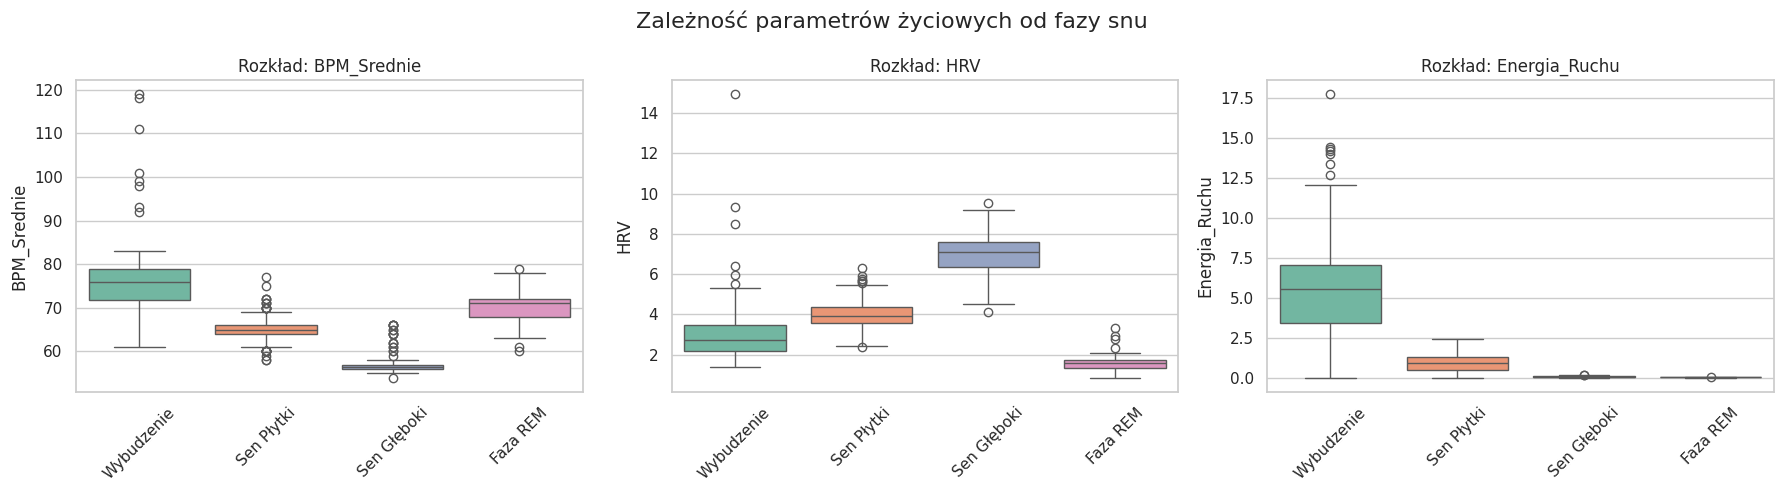

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Zależność parametrów życiowych od fazy snu', fontsize=16)

for i, feature in enumerate(FEATURES):
    sns.boxplot(ax=axes[i], x=TARGET, y=feature, data=df_train, palette="Set2")
    axes[i].set_title(f'Rozkład: {feature}')
    axes[i].set_xticklabels(LABELS, rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1282/2230783788.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=FEATURES, ax=ax2, palette="viridis")


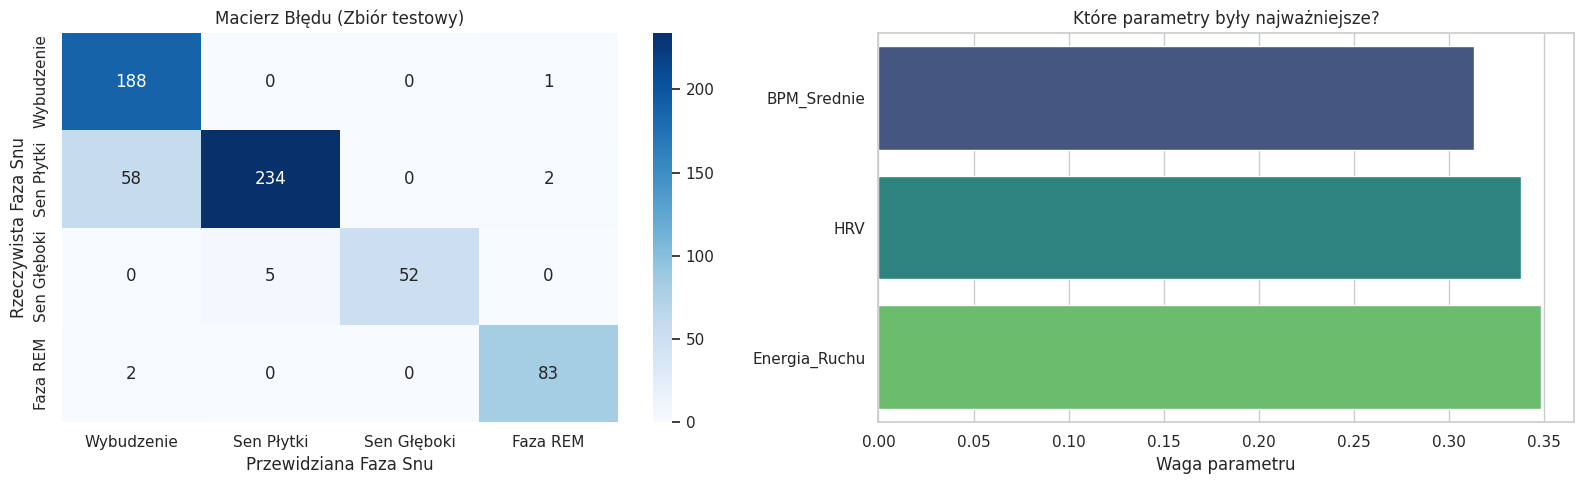

In [ ]:

model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=LABELS, yticklabels=LABELS)
ax1.set_title('Macierz Błędu (Zbiór testowy)')
ax1.set_ylabel('Rzeczywista Faza Snu')
ax1.set_xlabel('Przewidziana Faza Snu')

importances = model.feature_importances_
sns.barplot(x=importances, y=FEATURES, ax=ax2, palette="viridis")
ax2.set_title('Które parametry były najważniejsze?')
ax2.set_xlabel('Waga parametru')

plt.tight_layout()
plt.show()

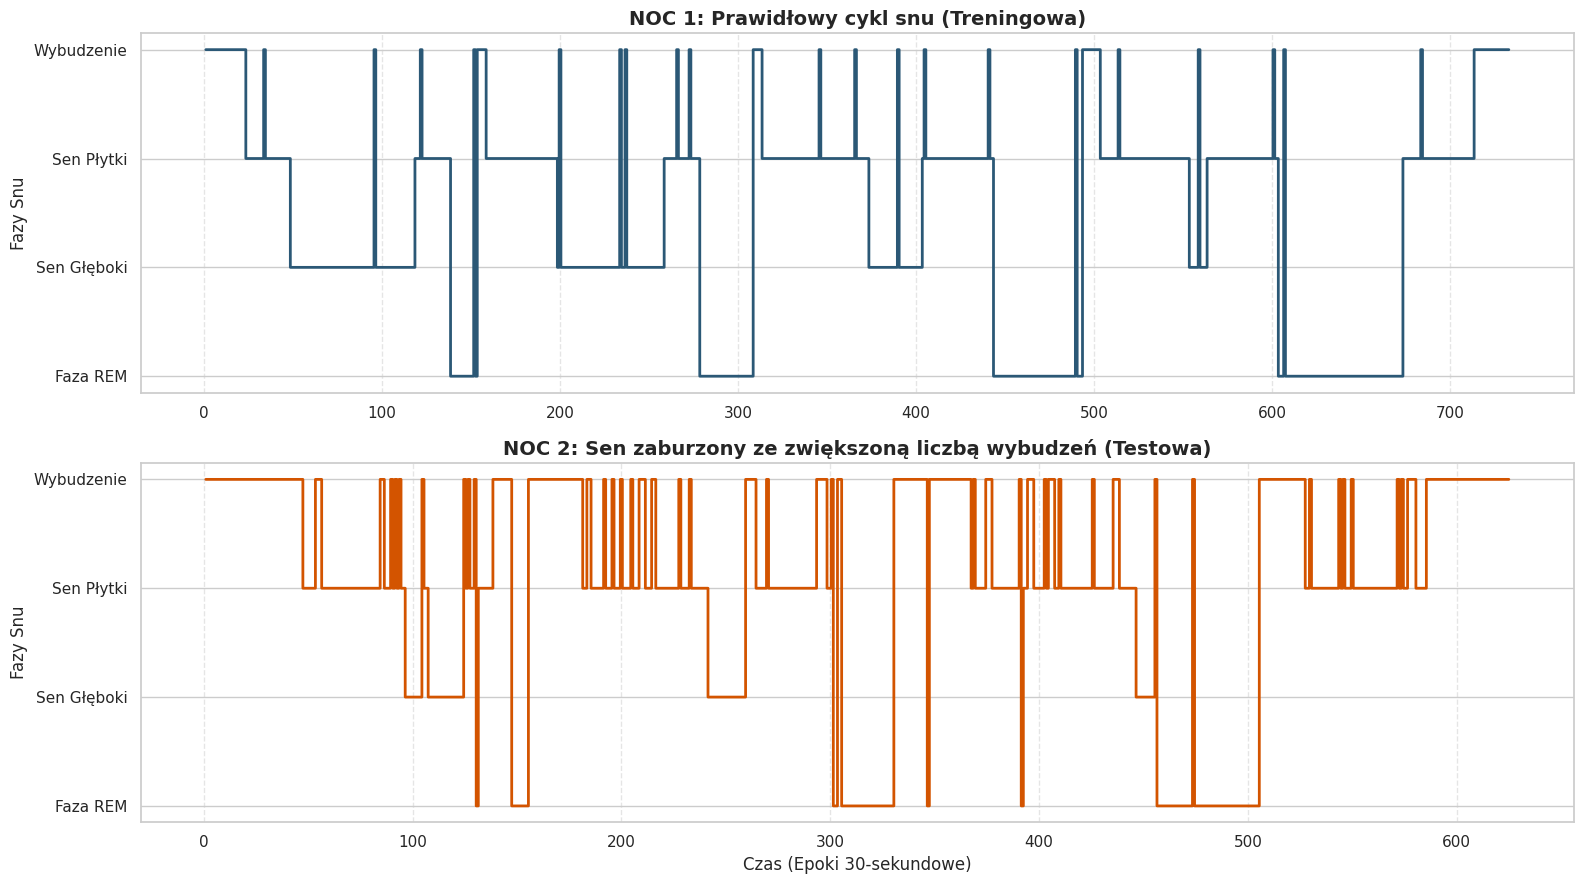

In [ ]:

df_train['Przewidziana_Faza'] = model.predict(X_train_scaled)
df_test['Przewidziana_Faza'] = y_pred

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharey=True)

ax1.step(df_train['Epoka'], df_train['Przewidziana_Faza'], where='mid', color='#2b5876', linewidth=2)
ax1.set_title('NOC 1: Prawidłowy cykl snu (Treningowa)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Fazy Snu', fontsize=12)
ax1.set_yticks([0, 1, 2, 3])
ax1.set_yticklabels(LABELS)
ax1.grid(axis='x', linestyle='--', alpha=0.5)


ax2.step(df_test['Epoka'], df_test['Przewidziana_Faza'], where='mid', color='#d35400', linewidth=2)
ax2.set_title('NOC 2: Sen zaburzony ze zwiększoną liczbą wybudzeń (Testowa)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Czas (Epoki 30-sekundowe)', fontsize=12)
ax2.set_ylabel('Fazy Snu', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

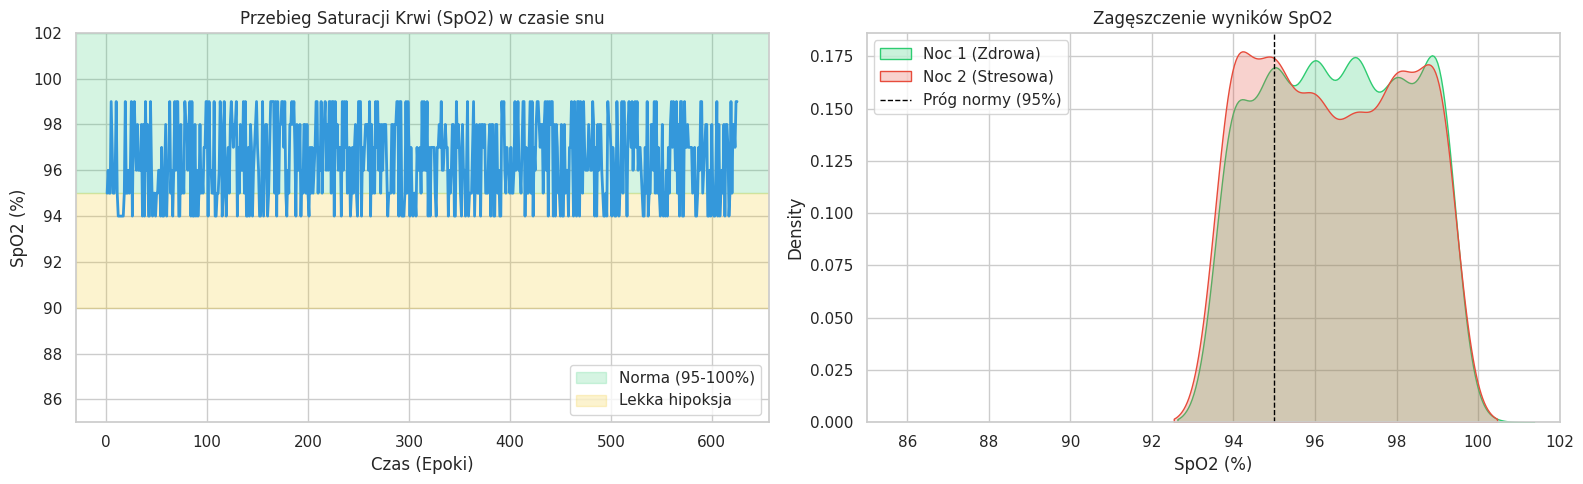

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


ax1.plot(df_test['Epoka'], df_test['SPO2'], color='#3498db', linewidth=2)
ax1.set_title('Przebieg Saturacji Krwi (SpO2) w czasie snu', fontsize=12)
ax1.set_xlabel('Czas (Epoki)')
ax1.set_ylabel('SpO2 (%)')
ax1.set_ylim(85, 102)
ax1.axhspan(95, 102, color='#2ecc71', alpha=0.2, label='Norma (95-100%)')
ax1.axhspan(90, 95, color='#f1c40f', alpha=0.2, label='Lekka hipoksja')
ax1.legend(loc='lower right')

sns.kdeplot(data=df_train['SPO2'], ax=ax2, color='#2ecc71', fill=True, label='Noc 1 (Zdrowa)')
sns.kdeplot(data=df_test['SPO2'], ax=ax2, color='#e74c3c', fill=True, label='Noc 2 (Stresowa)')
ax2.set_title('Zagęszczenie wyników SpO2', fontsize=12)
ax2.set_xlabel('SpO2 (%)')
ax2.set_xlim(85, 102)
ax2.axvline(x=95, color='black', linestyle='--', linewidth=1, label='Próg normy (95%)')
ax2.legend()

plt.tight_layout()
plt.show()